In [64]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [65]:
df = pd.read_csv("../dataset/clean_data.csv")

In [66]:
df.head()

,id,Unnamed: 6,founded_at,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,c:6669,San Francisco CA 94105,1/1/2007,2.2493,3.0027,4.6685,6.7041,3,3,375000,...,c:6669,0,1,0,0,0,0,1.0000,0,1
1,c:16283,San Francisco CA 94105,1/1/2000,5.1260,9.9973,7.0055,7.0055,9,4,40100000,...,c:16283,1,0,0,1,1,1,4.7500,1,1
2,c:65620,San Diego CA 92121,3/18/2009,1.0329,1.0329,1.4575,2.2055,5,1,2600000,...,c:65620,0,0,1,0,0,0,4.0000,1,1
3,c:42668,Cupertino CA 95014,1/1/2002,3.1315,5.3151,6.0027,6.0027,5,3,40000000,...,c:42668,0,0,0,1,1,1,3.3333,1,1
4,c:65806,San Francisco CA 94105,8/1/2010,0.0000,1.6685,0.0384,0.0384,2,2,1300000,...,c:65806,1,1,0,0,0,0,1.0000,1,0


In [67]:
features = [
    "funding_total_usd",
    "funding_rounds",
    "milestones",
    "relationships",
    "age_first_funding_year",
    "avg_participants",
    "category_code"
]

In [68]:
le_category = LabelEncoder()

df["category_code"] = le_category.fit_transform(
    df["category_code"]
)

In [69]:
X = df[features]

y = df["status"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [71]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [72]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy : 0.7405405405405405
              precision    recall  f1-score   support

           0       0.63      0.62      0.62        65
           1       0.80      0.81      0.80       120

    accuracy                           0.74       185
   macro avg       0.72      0.71      0.71       185
weighted avg       0.74      0.74      0.74       185



In [73]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy : 0.6864864864864865
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        65
           1       0.77      0.73      0.75       120

    accuracy                           0.69       185
   macro avg       0.66      0.67      0.66       185
weighted avg       0.69      0.69      0.69       185



In [74]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy : 0.7567567567567568
              precision    recall  f1-score   support

           0       0.66      0.63      0.65        65
           1       0.80      0.82      0.81       120

    accuracy                           0.76       185
   macro avg       0.73      0.73      0.73       185
weighted avg       0.75      0.76      0.76       185



In [75]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy : 0.7621621621621621
              precision    recall  f1-score   support

           0       0.67      0.65      0.66        65
           1       0.81      0.82      0.82       120

    accuracy                           0.76       185
   macro avg       0.74      0.74      0.74       185
weighted avg       0.76      0.76      0.76       185



In [76]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy : 0.7621621621621621
              precision    recall  f1-score   support

           0       0.67      0.65      0.66        65
           1       0.81      0.82      0.82       120

    accuracy                           0.76       185
   macro avg       0.74      0.74      0.74       185
weighted avg       0.76      0.76      0.76       185



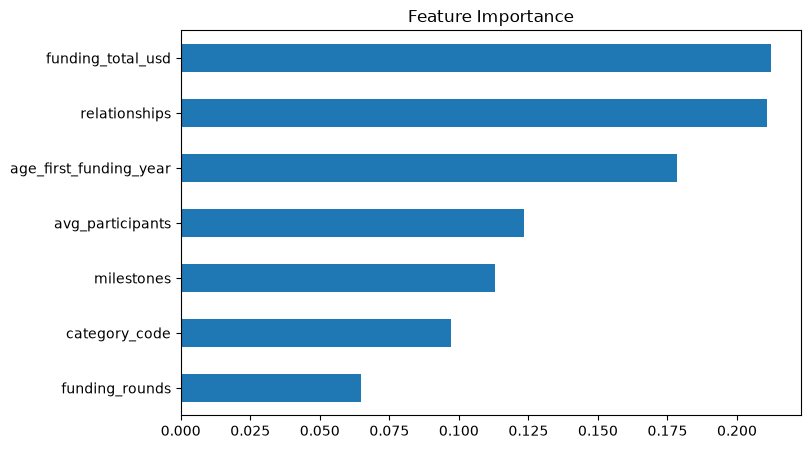

In [77]:
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

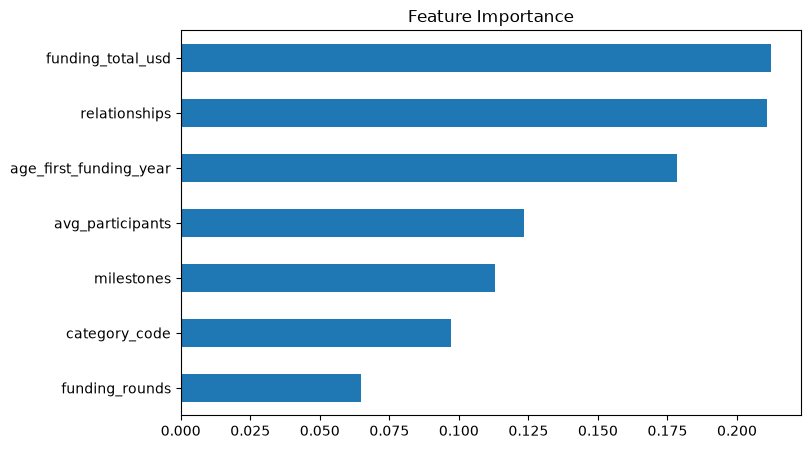

In [78]:
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

In [79]:
import os

os.makedirs("models", exist_ok=True)

In [80]:
os.makedirs("../models", exist_ok=True)

In [81]:
import os
import joblib

# Create the models folder in the project root
os.makedirs("../models", exist_ok=True)

joblib.dump(rf, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le_category, "../models/category_encoder.pkl")

print("Models saved successfully!")

Models saved successfully!


In [82]:
df[[
    "funding_total_usd",
    "funding_rounds",
    "milestones",
    "relationships",
    "age_first_funding_year",
    "avg_participants",
    "category_code",
    "status"
]].sample(10, random_state=42)

,funding_total_usd,funding_rounds,milestones,relationships,age_first_funding_year,avg_participants,category_code,status
323,2000000,3,2,16,0.7534,3.6667,31,1
861,7800000,1,2,3,2.5342,2.0000,30,1
30,10500000,2,1,3,1.3534,2.0000,22,0
837,8000000,1,1,2,9.7315,3.0000,30,0
294,13130000,5,1,1,1.2384,2.0000,34,0
63,4000000,1,0,0,6.3726,3.0000,30,0
215,52800000,3,0,5,6.8932,5.3333,28,1
168,4705910,5,3,5,0.7288,3.0000,18,1
554,41000000,2,2,11,0.0000,1.5000,22,0
873,12800000,2,1,5,1.9671,2.5000,18,1


In [83]:
import os

print(os.path.abspath("../models/model.pkl"))
print(os.path.exists("../models/model.pkl"))
print(os.path.getsize("../models/model.pkl"))

c:\Users\HP\Documents\AI-Startup-Success-Predictor\models\model.pkl
True
4618249


In [84]:
import joblib

model = joblib.load("../models/model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [85]:
import joblib

# Check scaler
try:
    scaler = joblib.load("../models/scaler.pkl")
    print("✅ Scaler loaded successfully")
    print(type(scaler))
except Exception as e:
    print("❌ Scaler Error:", e)

# Check encoder
try:
    encoder = joblib.load("../models/category_encoder.pkl")
    print("✅ Encoder loaded successfully")
    print(type(encoder))
except Exception as e:
    print("❌ Encoder Error:", e)

✅ Scaler loaded successfully
<class 'sklearn.preprocessing._data.StandardScaler'>
✅ Encoder loaded successfully
<class 'sklearn.preprocessing._label.LabelEncoder'>
